# Milestone 3: Week 5 & 6 - Modeling & Advanced Analysis

In [320]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [322]:
df = pd.read_csv("netflix_cleaned_week4.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_number,duration_type,year_added,duration_num,content_length_category,original_vs_licensed
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020-01-01,PG-13,90 min,Documentaries,"as her father nears the end of his life, filmm...",90.0,min,2021.0,90.0,Medium Movie,Licensed
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021-01-01,TV-MA,2 seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","after crossing paths at a party, a cape town t...",2.0,season,2021.0,2.0,Multi Season Show,Original
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021-01-01,TV-MA,1 season,"Crime Tv Shows, International Tv Shows, Tv Act...",to protect his family from a powerful drug lor...,1.0,season,2021.0,1.0,Single Season Show,Original
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021-01-01,TV-MA,1 season,"Docuseries, Reality Tv","feuds, flirtations and toilet talk go down amo...",1.0,season,2021.0,1.0,Single Season Show,Original
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021-01-01,TV-MA,2 seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",in a city of coaching centers known to train i...,2.0,season,2021.0,2.0,Multi Season Show,Original


## Task 1: Use clustering to group Netflix titles by genre, duration, and ratings.

In [325]:
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [326]:
df_cluster = df[['listed_in', 'duration_int', 'rating']].copy()

In [327]:
df_cluster = df_cluster.dropna()

In [328]:
le_genre = LabelEncoder()
le_rating = LabelEncoder()

df_cluster['genre_encoded'] = le_genre.fit_transform(df_cluster['listed_in'])
df_cluster['rating_encoded'] = le_rating.fit_transform(df_cluster['rating'])

In [330]:
X = df_cluster[['genre_encoded', 'duration_int', 'rating_encoded']]

In [334]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

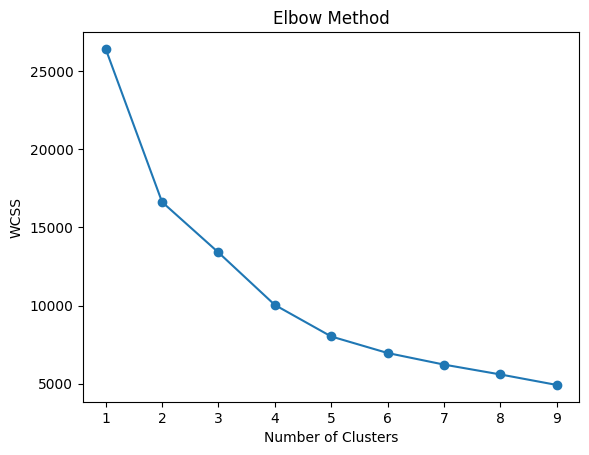

In [336]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [338]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

In [339]:
print(df_cluster['cluster'].value_counts())

cluster
2    2938
1    2617
3    2155
0    1094
Name: count, dtype: int64


In [340]:
df_cluster.groupby('cluster').mean(numeric_only=True)

,duration_int,genre_encoded,rating_encoded
cluster,,,
0,47.771481,95.659049,8.574040
1,9.494077,388.799771,7.896064
2,109.093601,215.161334,4.912866
3,100.838515,298.574942,8.043619


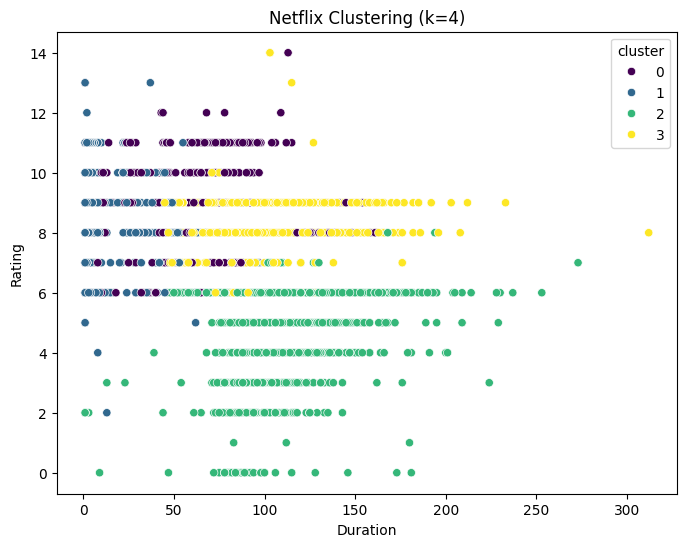

In [344]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_cluster['duration_int'],
    y=df_cluster['rating_encoded'],
    hue=df_cluster['cluster'],
    palette='viridis'
)

plt.title('Netflix Clustering (k=4)')
plt.xlabel('Duration')
plt.ylabel('Rating')
plt.show()

## Task 2: Classification of content type (Movie vs. TV Show) based on features.

In [347]:
df_class = df.copy()

In [348]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_class['type_encoded'] = le.fit_transform(df_class['type'])

In [349]:
df_class['rating_encoded'] = le.fit_transform(df_class['rating'])
df_class['country_encoded'] = le.fit_transform(df_class['country'])

In [350]:
df_class['release_year'] = pd.to_numeric(df_class['release_year'], errors='coerce')

In [352]:
X = df_class[['release_year', 'duration_int', 'rating_encoded', 'country_encoded']]
y = df_class['type_encoded']

In [358]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [360]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train);

In [361]:
y_pred = model.predict(X_test)

In [362]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9988649262202043


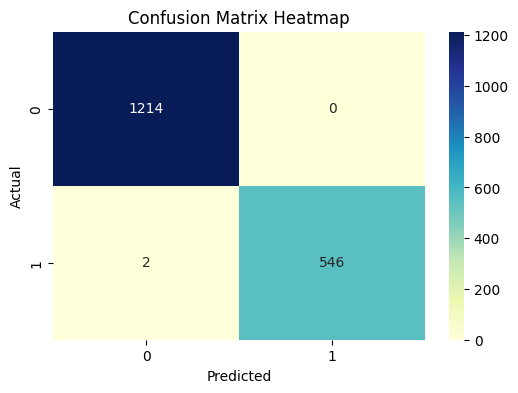

In [408]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')

plt.show()

## Task 3: Analyze key drivers for content availability across countries and genres.

In [392]:
top_countries = df['country'].value_counts().head(5).index

In [394]:
top_genres = df['listed_in'].value_counts().head(8).index

In [396]:
df_filtered = df[
    (df['country'].isin(top_countries)) &
    (df['listed_in'].isin(top_genres))
]

In [398]:
pivot = pd.crosstab(df_filtered['listed_in'], df_filtered['country'])

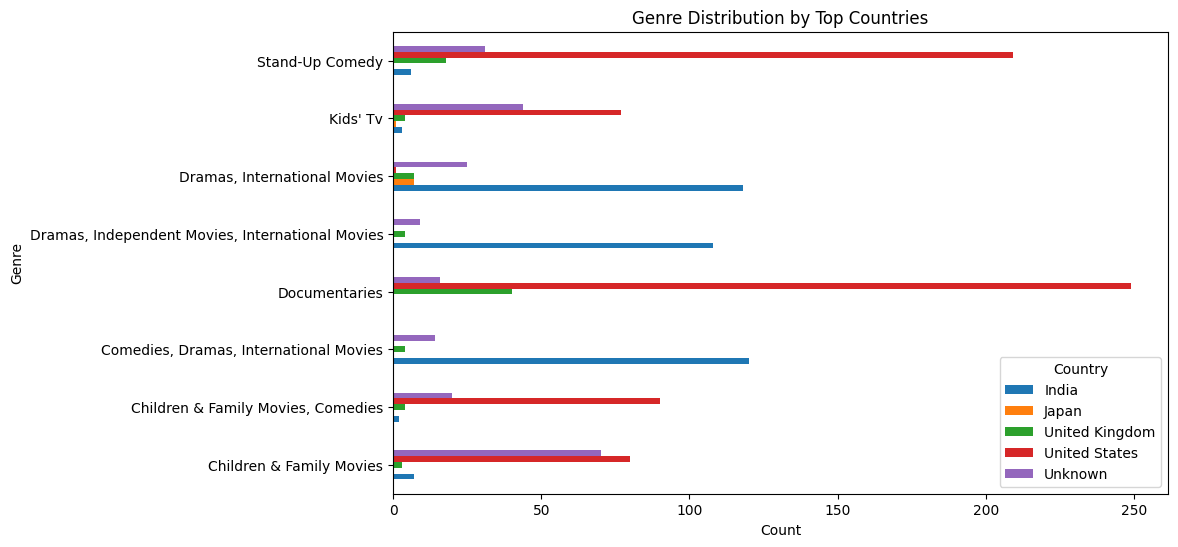

In [404]:
pivot.plot(kind='barh', figsize=(10,6))

plt.title('Genre Distribution by Top Countries')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.legend(title='Country')
plt.show()

## Task 4: Use feature importance methods to interpret results.

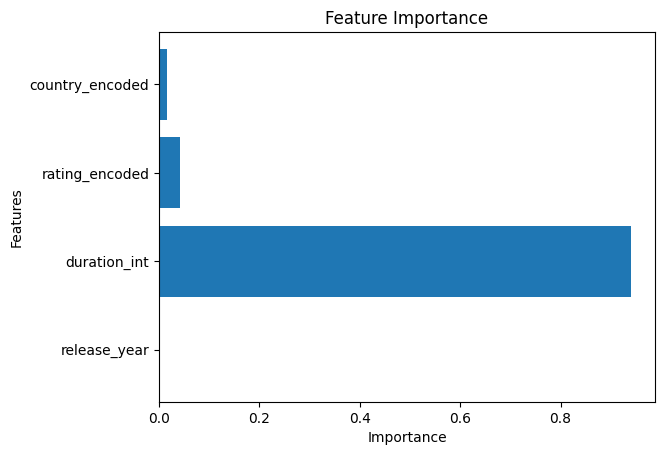

In [386]:
plt.barh(X.columns, importances)

plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')

plt.show()